# Simulation-to-experiment validation gate

This executed notebook checks whether the real L6 spectrum resembles the enhanced synthetic training distribution before trusting inverse-model inference. It uses the independently trained quick 70 meV artifact only as a pipeline diagnostic, not as a publication model.

In [1]:
from pathlib import Path
import os
import tempfile
import numpy as np
import matplotlib.pyplot as plt

from hamlet.data import as_supervised
from hamlet.io import load_reference_heisenberg_datasets, load_spectroscopy_csv
from hamlet.preprocessing import make_local_windows
from hamlet.training import (
    TrainingDistributionProfile, TrainingPreprocessingConfig, TrainingRun,
    augment_experimental_like, grouped_split, prepare_training_dataset, recommend_artifact,
)

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
REFERENCE = ROOT / 'reference' / 'Inhomogeneous-Heisenberg-HL'
BANK = ROOT / 'models' / 'heisenberg_cutoff_bank_quick'
EXPERIMENT = REFERENCE / 'data' / 'experimental' / 'ChainIH_L6_SYM.csv'
RESULTS = ROOT / 'results' / 'validation_gate'
RESULTS.mkdir(parents=True, exist_ok=True)
print('workspace:', ROOT)

workspace: /u/06/lupig1/data/Desktop/Hamiltonian_Learning_package


## Reconstruct the exact enhanced training distribution

In [2]:
raw = load_reference_heisenberg_datasets([
    REFERENCE / 'data' / 'synthetic' / 'dataset_30_40.npz',
    REFERENCE / 'data' / 'synthetic' / 'dataset_35_45.npz',
])
enhanced = augment_experimental_like(raw, seed=42, noise=0.002)
prepared = prepare_training_dataset(
    enhanced, TrainingPreprocessingConfig(bias_cutoff_mev=70.0, output_points=200)
)
supervised = as_supervised(prepared.dataset, 'local_bonds')
split = grouped_split(supervised, validation_fraction=0.2, test_fraction=0.1, seed=42)
profile = TrainingDistributionProfile.fit(
    split.train.inputs, split.train.targets, max_references=256, seed=42
)
print(f'{raw.n_samples} chains; {split.train.inputs.shape[0]} training windows')
print('training OOD score quantiles:', profile.to_metadata()['score_quantiles'])

3000 chains; 21000 training windows
training OOD score quantiles: [0.941832423210144, 1.266049861907959, 1.3675881624221802, 1.587841510772705]


## Score the experiment and retrieve nearest synthetic windows

In [3]:
bias, experimental_map = load_spectroscopy_csv(EXPERIMENT)
choice = recommend_artifact(BANK, bias)
run = TrainingRun.load(choice.artifact_path)
processed_experiment = run.preprocessing_config.build_preprocessor().transform_map(
    experimental_map, bias
)
experimental_windows = make_local_windows(processed_experiment).reshape(
    processed_experiment.shape[0] - 2, -1
)
experimental_scores = profile.score(experimental_windows)
nearest = profile.nearest(experimental_windows)
print(choice.reason)
print('experimental window scores:', np.round(experimental_scores, 3))
print('95% training threshold:', round(profile.threshold_95, 3))
print('fraction outside:', np.mean(experimental_scores > profile.threshold_95))
print('nearest synthetic target pairs [meV]:\n', np.round(nearest.targets, 2))

2026-08-18 17:01:09.188885: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-08-18 17:01:09.189661: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-08-18 17:01:09.285710: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-08-18 17:01:12.187323: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

selected the lowest validation MAE (0.899 meV) among cutoffs fully covered by the experiment; selected cutoff: 70 meV
experimental window scores: [1.458 1.228 1.261 1.891]
95% training threshold: 1.368
fraction outside: 0.5
nearest synthetic target pairs [meV]:
 [[31.57 30.15]
 [31.06 30.48]
 [32.23 35.58]
 [33.48 31.34]]


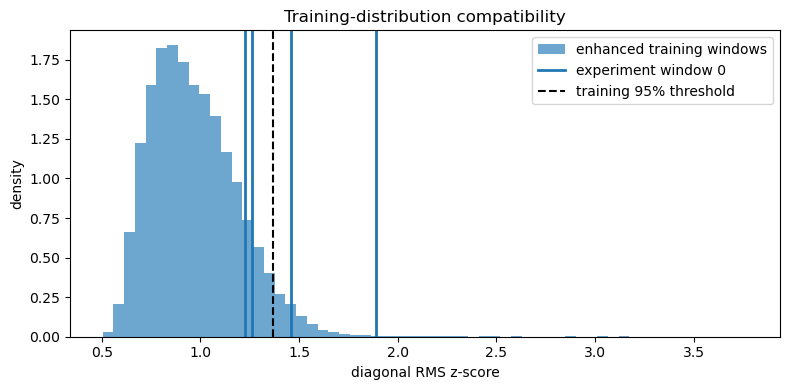

In [4]:
train_scores = profile.score(split.train.inputs)
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(train_scores, bins=60, density=True, alpha=0.65, label='enhanced training windows')
for i, score in enumerate(experimental_scores):
    ax.axvline(score, linewidth=2, label=f'experiment window {i}' if i == 0 else None)
ax.axvline(profile.threshold_95, color='k', linestyle='--', label='training 95% threshold')
ax.set(xlabel='diagonal RMS z-score', ylabel='density', title='Training-distribution compatibility')
ax.legend()
fig.tight_layout()
fig.savefig(RESULTS / 'ood_score_distribution.png', dpi=170)
plt.show()

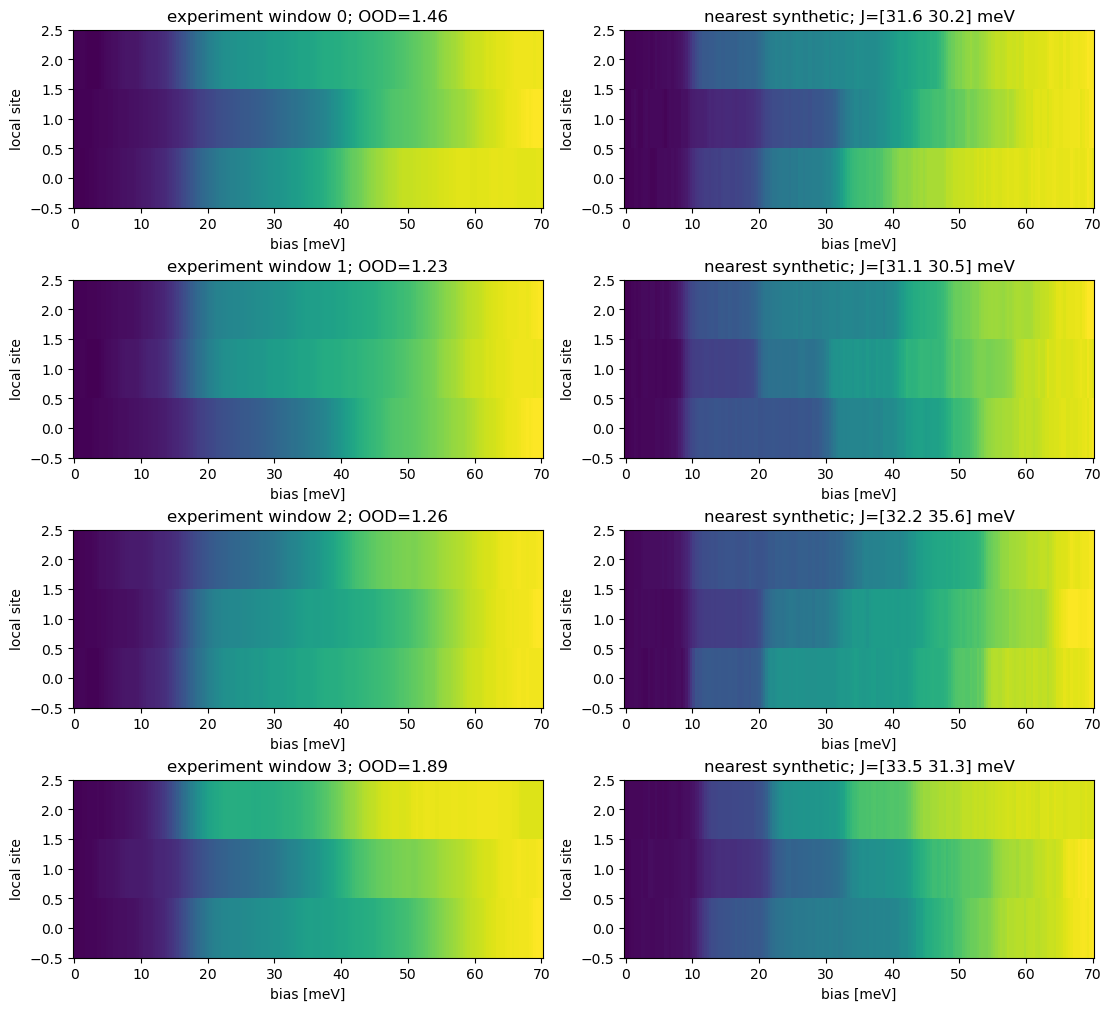

In [5]:
n_windows = experimental_windows.shape[0]
fig, axes = plt.subplots(n_windows, 2, figsize=(11, 2.5 * n_windows), constrained_layout=True)
for i in range(n_windows):
    exp_window = experimental_windows[i].reshape(3, 200)
    ref_window = nearest.inputs[i].reshape(3, 200)
    axes[i, 0].pcolormesh(prepared.dataset.bias_mev, np.arange(3), exp_window, shading='auto')
    axes[i, 1].pcolormesh(prepared.dataset.bias_mev, np.arange(3), ref_window, shading='auto')
    axes[i, 0].set_title(f'experiment window {i}; OOD={experimental_scores[i]:.2f}')
    axes[i, 1].set_title(f'nearest synthetic; J={nearest.targets[i].round(1)} meV')
    for ax in axes[i]: ax.set(xlabel='bias [meV]', ylabel='local site')
fig.savefig(RESULTS / 'nearest_synthetic_windows.png', dpi=170)
plt.show()

## Inference with compatibility diagnostics

couplings [meV]: [32.67 31.68 31.73 32.35 29.45]
diagnostic status: review
- one model cannot estimate ensemble uncertainty
- 12.5% of local predictions lie outside the training range
- 50.0% of experimental windows lie outside the central training distribution


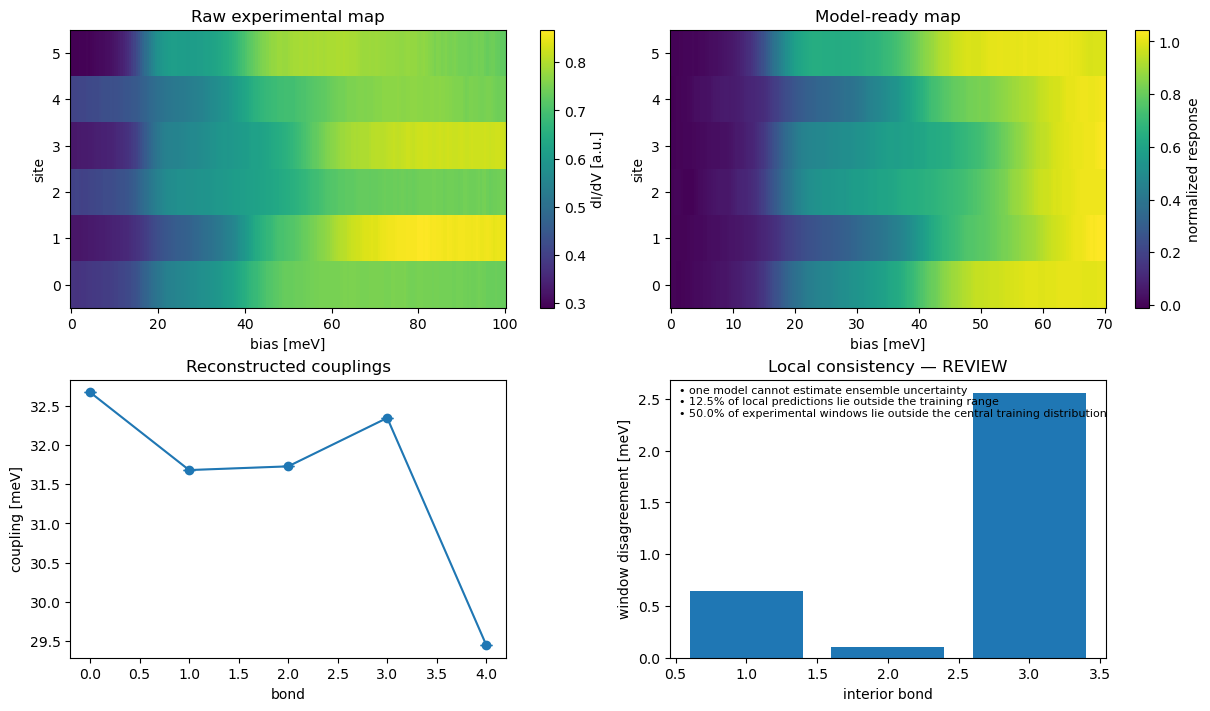

In [6]:
analyzer = run.create_analyzer()
analyzer.distribution_profile = profile
result = analyzer.analyze_csv(EXPERIMENT)
print('couplings [meV]:', np.round(result.coupling_mean, 2))
print('diagnostic status:', result.diagnostics.status)
for warning in result.diagnostics.warnings: print('-', warning)
figure = result.plot_summary()
figure.savefig(RESULTS / 'experimental_inference_qc.png', dpi=170)
plt.show()

## Forward-physics check of the inferred Hamiltonian

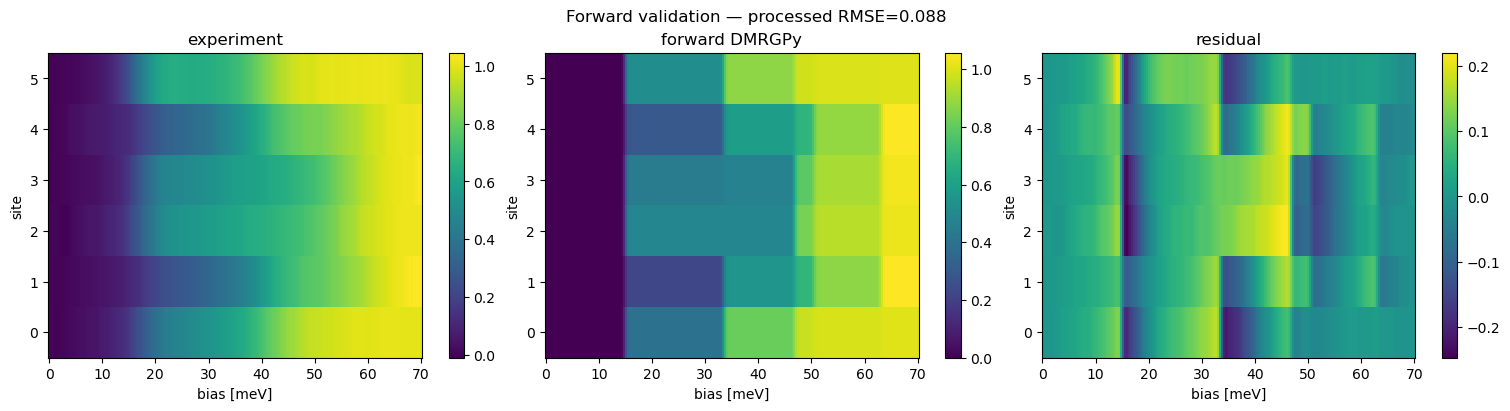

forward processed-map RMSE: 0.08756828308105469


In [7]:
from hamlet.simulation import DmrgpySimulator, SpectroscopyProtocol
from hamlet.systems import InhomogeneousHeisenbergChain

forward_error = None
try:
    system = InhomogeneousHeisenbergChain(result.coupling_mean)
    protocol = SpectroscopyProtocol.uniform(
        (0.0, 70.0), points=200, broadening_mev=0.5, output_quantity='didv'
    )
    previous = Path.cwd()
    with tempfile.TemporaryDirectory(dir='/tmp') as temporary:
        os.chdir(temporary)
        try:
            forward = DmrgpySimulator().simulate(system, protocol)
        finally:
            os.chdir(previous)
    forward_processed = run.preprocessing_config.build_preprocessor().transform_map(
        forward.spectral_map, forward.bias_mev
    )
    residual = processed_experiment - forward_processed
    forward_error = float(np.sqrt(np.mean(residual**2)))
    fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
    for ax, values, title in zip(axes, [processed_experiment, forward_processed, residual],
                                  ['experiment', 'forward DMRGPy', 'residual']):
        image = ax.pcolormesh(prepared.dataset.bias_mev, np.arange(6), values, shading='auto')
        ax.set(title=title, xlabel='bias [meV]', ylabel='site')
        fig.colorbar(image, ax=ax)
    fig.suptitle(f'Forward validation — processed RMSE={forward_error:.3f}')
    fig.savefig(RESULTS / 'forward_validation.png', dpi=170)
    plt.show()
except Exception as exc:
    print('Forward simulation unavailable:', type(exc).__name__, exc)
print('forward processed-map RMSE:', forward_error)

## Decision rule

Do not promote the quick artifact. If the experiment is outside the enhanced training distribution or the forward residual is structurally large, recalibrate augmentation first. Once coverage is credible, train three-seed standard ensembles at 50 and 70 meV and repeat this notebook unchanged.